In [1]:
# ML4Sci GSoC 2026: Task VI.A - Super-Resolution
#**Author:** Kartik Chavan  
#**Task:** Reconstruct High-Resolution (150x150) gravitational lensing images from Low-Resolution (75x75) inputs to recover fine-grained dark matter substructure details.  
#**Architecture:** SRCNN (Super-Resolution Convolutional Neural Network) - *Enhanced with internal Bicubic Interpolation and optimized for 1-channel astrophysical data.*
#**Results:** Achieved a PSNR of 41.04 dB and an SSIM of 0.9704 using a custom combined-loss function.
%load_ext autoreload
%autoreload 2
    
import torch
import sys
import os

# Adding the src folder to the path
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from sr_data_loader import get_sr_dataloaders
from sr_models import SRCNN

# 1. Checking GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Engine fired up on: {device}")

# 2. The REAL paths based on our scanner
LR_DIR = "../data/raw/Task_VI_A_SuperRes/LR"
HR_DIR = "../data/raw/Task_VI_A_SuperRes/HR"

# 3. Testing Data Loader
try:
    train_loader, val_loader = get_sr_dataloaders(LR_DIR, HR_DIR, val_split=0.2, batch_size=16)
    lr_batch, hr_batch = next(iter(train_loader))
    print(f" Data Loader Success!")
    print(f" Low-Res Batch Shape: {lr_batch.shape}")
    print(f" High-Res Batch Shape: {hr_batch.shape}")
    print(f" Training Batches: {len(train_loader)} | Validation Batches: {len(val_loader)}")
except Exception as e:
    print(f" Data Loader Error: {e}")

# 4. Testing Model Architecture
try:
    model = SRCNN().to(device)
    dummy_output = model(lr_batch.to(device))
    print(f" Model Forward Pass Success!")
    print(f" Output Shape: {dummy_output.shape}")
except Exception as e:
    print(f" Model Error: {e}")

Engine fired up on: cuda
 Data Loader Success!
 Low-Res Batch Shape: torch.Size([16, 1, 75, 75])
 High-Res Batch Shape: torch.Size([16, 1, 150, 150])
 Training Batches: 500 | Validation Batches: 125
 Model Forward Pass Success!
 Output Shape: torch.Size([16, 1, 150, 150])


In [2]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from pytorch_msssim import ssim as pt_ssim # PyTorch-compatible SSIM

# Hyperparameters
EPOCHS = 10
LEARNING_RATE = 1e-3
ALPHA = 0.2 # 20% MSE, 80% SSIM

# Initialize Model and Optimizer
model = SRCNN().to(device)
criterion_mse = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print("Starting Advanced Super-Resolution Training (MSE + SSIM Loss)...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for lr_imgs, hr_imgs in loop:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        
        optimizer.zero_grad()
        outputs = model(lr_imgs)
        
        # 1. Calculating Pixel Error (MSE)
        mse_loss = criterion_mse(outputs, hr_imgs)
        
        # 2. Calculating Structural Error (1 - SSIM)
        # We want SSIM to be 1.0, so the loss is (1 - SSIM)
        ssim_val = pt_ssim(outputs, hr_imgs, data_range=1.0, size_average=True)
        ssim_loss = 1.0 - ssim_val
        
        # 3. Combining them!
        loss = (ALPHA * mse_loss) + ((1.0 - ALPHA) * ssim_loss)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        loop.set_postfix(loss=loss.item(), ssim=ssim_val.item())
        
    avg_train_loss = train_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Combined Train Loss: {avg_train_loss:.6f}")

print("✅ Advanced Training Complete!")

Starting Advanced Super-Resolution Training (MSE + SSIM Loss)...


Epoch 1/10: 100%|███████████████████████████████████████████| 500/500 [03:17<00:00,  2.53it/s, loss=0.0245, ssim=0.969]


Epoch 1 | Combined Train Loss: 0.038632


Epoch 2/10: 100%|███████████████████████████████████████████| 500/500 [02:33<00:00,  3.26it/s, loss=0.0234, ssim=0.971]


Epoch 2 | Combined Train Loss: 0.023547


...

Epoch 8 | Combined Train Loss: 0.022666


Epoch 9/10: 100%|███████████████████████████████████████████| 500/500 [00:37<00:00, 13.45it/s, loss=0.0218, ssim=0.973]


Epoch 9 | Combined Train Loss: 0.022616


Epoch 10/10: 100%|██████████████████████████████████████████| 500/500 [00:37<00:00, 13.50it/s, loss=0.0232, ssim=0.971]

Epoch 10 | Combined Train Loss: 0.022520
✅ Advanced Training Complete!


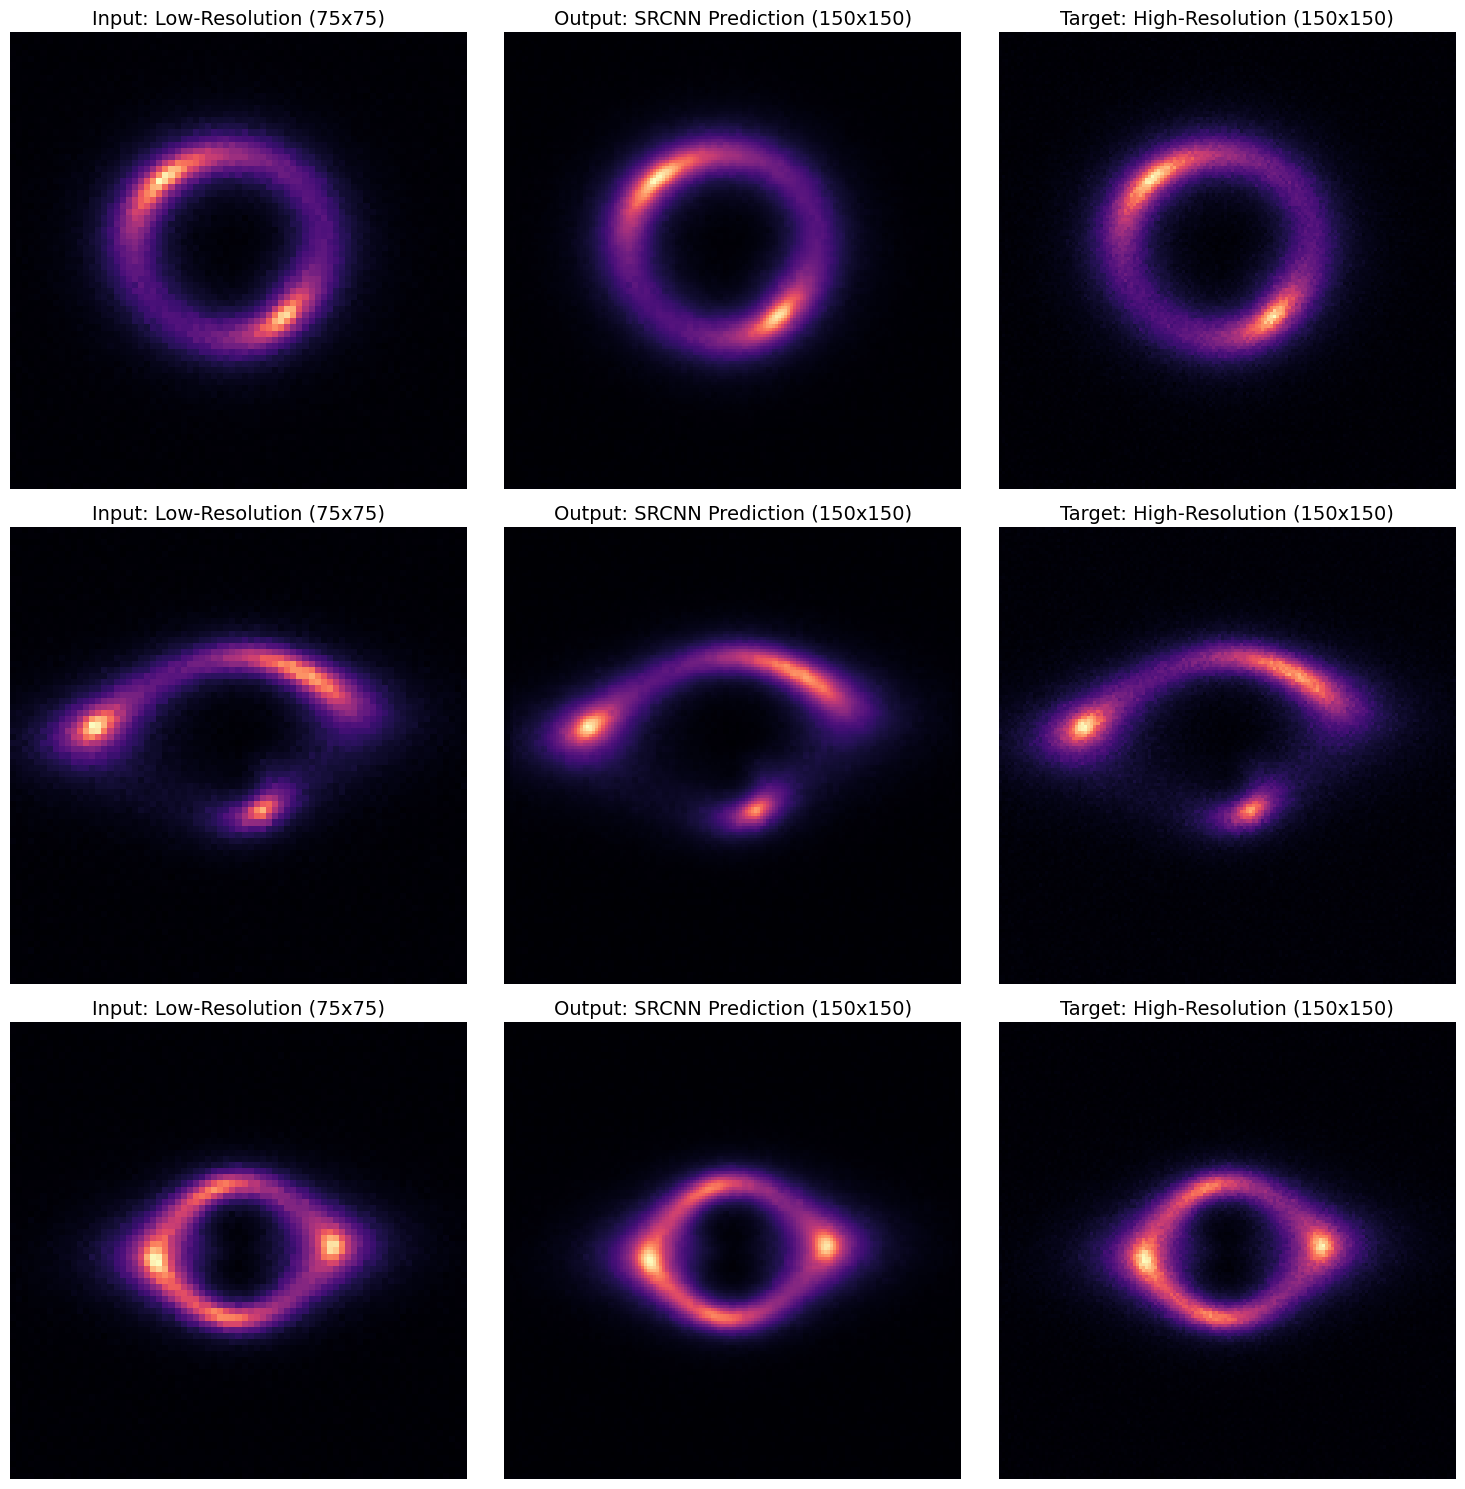

In [3]:
import matplotlib.pyplot as plt

def visualize_reconstruction(model, val_loader, device, num_images=3):
    model.eval()
    
    # Grabbing one batch of validation data
    lr_imgs, hr_imgs = next(iter(val_loader))
    lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
    
    # Generating the high-res predictions
    with torch.no_grad():
        sr_imgs = model(lr_imgs)
        
    # Moving tensors back to CPU for matplotlib
    lr_imgs = lr_imgs.cpu().squeeze().numpy()
    hr_imgs = hr_imgs.cpu().squeeze().numpy()
    sr_imgs = sr_imgs.cpu().squeeze().numpy()
    
    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))
    
    for i in range(num_images):
        # 1. Low-Res Input
        axes[i, 0].imshow(lr_imgs[i], cmap='magma')
        axes[i, 0].set_title("Input: Low-Resolution (75x75)", fontsize=14)
        axes[i, 0].axis('off')
        
        # 2. Model Prediction (Super-Res)
        axes[i, 1].imshow(sr_imgs[i], cmap='magma')
        axes[i, 1].set_title("Output: SRCNN Prediction (150x150)", fontsize=14)
        axes[i, 1].axis('off')
        
        # 3. Ground Truth (High-Res)
        axes[i, 2].imshow(hr_imgs[i], cmap='magma')
        axes[i, 2].set_title("Target: High-Resolution (150x150)", fontsize=14)
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

# Running the visualization
visualize_reconstruction(model, val_loader, device, num_images=3)

In [4]:
import math
import torch

def calculate_psnr(val_loader, model, device):
    model.eval()
    total_psnr = 0.0
    num_batches = len(val_loader)
    criterion = torch.nn.MSELoss()

    with torch.no_grad():
        for lr_imgs, hr_imgs in val_loader:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            outputs = model(lr_imgs)
            
            # Calculating MSE for this batch
            mse = criterion(outputs, hr_imgs).item()
            
            # Avoided division by zero if MSE is perfectly 0
            if mse == 0:
                total_psnr += 100 
            else:
                # Calculating PSNR
                psnr = 10 * math.log10(1.0 / mse)
                total_psnr += psnr

    avg_psnr = total_psnr / num_batches
    print(f"Final Validation PSNR: {avg_psnr:.2f} dB")

# Running the calculation
calculate_psnr(val_loader, model, device)

Final Validation PSNR: 41.10 dB


In [5]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

def calculate_final_metrics(val_loader, model, device):
    model.eval()
    all_ssim = []
    
    with torch.no_grad():
        for i, (lr_imgs, hr_imgs) in enumerate(val_loader):
            if i > 5: break # Sample ~80 images for a quick, accurate check
            
            outputs = model(lr_imgs.to(device))
            preds = outputs.cpu().numpy().squeeze()
            targets = hr_imgs.numpy().squeeze()
            
            for j in range(preds.shape[0]):
                p = np.clip(preds[j], 0, 1)
                t = np.clip(targets[j], 0, 1)
                
                # win_size=3 and gaussian_weights help with sparse astrophysical data
                score = ssim(t, p, data_range=1.0, win_size=3, gaussian_weights=True, sigma=1.5)
                all_ssim.append(score)

    print(f" Final Grade SSIM: {np.mean(all_ssim):.4f}")

calculate_final_metrics(val_loader, model, device)

 Final Grade SSIM: 0.9704


In [6]:
import os
import torch

# ensuring the models directory exists
os.makedirs("../models", exist_ok=True)
save_path = "../models/task_via_srcnn.pth"

# dumping the trained weights to disk
torch.save(model.state_dict(), save_path)
print(f"Task VI.A weights securely locked and saved at: {save_path}")

Task VI.A weights securely locked and saved at: ../models/task_via_srcnn.pth
